In [ ]:
from __future__ import annotations
import operator
from typing import TypedDict, List, Annotated
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel, Field
from typing import Literal
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

In [106]:
class Task(BaseModel):
    id: int
    title: str

    goal: str = Field(
        ...,
        description="One sentence describing what the reader should be able to do/understand after this section.",
    )
    bullets: List[str] = Field(
        ...,
        min_length=3,
        max_length=7,
        description="3-7 concrete, non-overlapping subpoints to cover in this section.",
    )
    target_words: int = Field(
        ...,
        description="Target word count for this section (120-450).",
    )
    section_type: Literal[
        "intro", "core", "examples", "checklist", "common_mistakes", "conclusion"
    ] = Field(
        ...,
        description="Use 'common_mistakes' exactly once in the plan.",
    )


In [107]:
class Plan(BaseModel):
    blog_title: str
    audience: str = Field(..., description="The target audience for the blog")
    tone: str = Field(..., description="The tone of the blog")
    tasks: List[Task]

In [108]:
class State(TypedDict):
    topic: str
    plan: Plan
    sections: Annotated[List[str], operator.add]
    final: str

In [ ]:
load_dotenv()  # Load environment variables from .env file
section_writer_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=os.getenv("GOOGLE_API_KEY") or os.getenv("GEMINI_API_KEY"),
)

planner_llm = ChatGroq(model="openai/gpt-oss-120b")

In [123]:
def orchestrator(state: State) -> dict:
    planner = planner_llm.with_structured_output(Plan)

    plan = planner.invoke(
        [
            SystemMessage(
                content=(
                    "You are a senior technical writer and developer advocate. Your job is to produce a "
                    "highly actionable outline for a technical blog post.\n\n"
                    "Hard requirements:\n"
                    "- Create 5–7 sections (tasks) that fit a technical blog.\n"
                    "- Each section must include:\n"
                    "  1) goal (1 sentence: what the reader can do/understand after the section)\n"
                    "  2) 3–7 bullets that are concrete, specific, and non-overlapping\n"
                    "  3) target word count (200–450)\n"
                    "- Include EXACTLY ONE section with section_type='common_mistakes'.\n\n"
                    "Make it technical (not generic):\n"
                    "- Assume the reader is a developer; use correct terminology.\n"
                    "- Prefer design/engineering structure: problem → intuition → approach → implementation → "
                    "trade-offs → testing/observability → conclusion.\n"
                    "- Bullets must be actionable and testable (e.g., 'Show a minimal code snippet for X', "
                    "'Explain why Y fails under Z condition', 'Add a checklist for production readiness').\n"
                    "- Explicitly include at least ONE of the following somewhere in the plan (as bullets):\n"
                    "  * a minimal working example (MWE) or code sketch\n"
                    "  * edge cases / failure modes\n"
                    "  * performance/cost considerations\n"
                    "  * security/privacy considerations (if relevant)\n"
                    "  * debugging tips / observability (logs, metrics, traces)\n"
                    "- Avoid vague bullets like 'Explain X' or 'Discuss Y'. Every bullet should state what "
                    "to build/compare/measure/verify.\n\n"
                    "Ordering guidance:\n"
                    "- Start with a crisp intro and problem framing.\n"
                    "- Build core concepts before advanced details.\n"
                    "- Include one section for common mistakes and how to avoid them.\n"
                    "- End with a practical summary/checklist and next steps.\n\n"
                    "Output must strictly match the Plan schema."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )

    return {"plan": plan}

In [111]:
def fanout(state:State):
    return [Send("worker", {"task":task,"topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks
            ]

In [112]:
def worker(payload: dict) -> dict:

    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    bullets_text = "\n- " + "\n- ".join(task.bullets)

    section_md = section_writer_llm.invoke(
        [
            SystemMessage(
    content=(
        "You are a senior technical writer and developer advocate. Write ONE section of a technical blog post in Markdown.\n\n"
        "Hard constraints:\n"
        "- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).\n"
        "- Stay close to the Target words (±15%).\n"
        "- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).\n\n"
        "Technical quality bar:\n"
        "- Be precise and implementation-oriented (developers should be able to apply it).\n"
        "- Prefer concrete details over abstractions: APIs, data structures, protocols, and exact terms.\n"
        "- When relevant, include at least one of:\n"
        "  * a small code snippet (minimal, correct, and idiomatic)\n"
        "  * a tiny example input/output\n"
        "  * a checklist of steps\n"
        "  * a diagram described in text (e.g., 'Flow: A -> B -> C')\n"
        "- Explain trade-offs briefly (performance, cost, complexity, reliability).\n"
        "- Call out edge cases / failure modes and what to do about them.\n"
        "- If you mention a best practice, add the 'why' in one sentence.\n\n"
        "Markdown style:\n"
        "- Start with a '## <Section Title>' heading.\n"
        "- Use short paragraphs, bullet lists where helpful, and code fences for code.\n"
        "- Avoid fluff. Avoid marketing language.\n"
        "- If you include code, keep it focused on the bullet being addressed.\n"
    )
)
,
            HumanMessage(
                content=(
                    f"Blog: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Section type: {task.section_type}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Bullets:{bullets_text}\n"
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [113]:
from pathlib import Path
def reducer(state: State) -> dict:

    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()
    
    final_md = f"# {title}\n\n{body}\n"

    # Save to file
    filename = "".join(c if c.isalnum() or c in (" ", "_", "-") else "" for c in title)
    filename = filename.strip().lower().replace(" ", "_") + ".md"
    Path(filename).write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [114]:
graph = StateGraph(State)
graph.add_node("orchestrate", orchestrator)
graph.add_node("worker", worker)
graph.add_node("reducer", reducer)

graph.add_edge(START, "orchestrate")
graph.add_conditional_edges("orchestrate", fanout, ["worker"])
graph.add_edge("worker", "reducer")
graph.add_edge("reducer", END)

app = graph.compile()

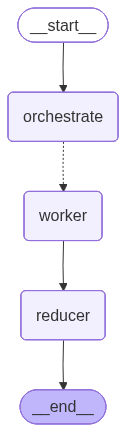

In [115]:
app

In [126]:
out = app.invoke({"topic": "Ancient China Martial Arts", "sections": []})
print(out["final"])

# Designing a Real‑Time Combat Engine for Ancient Chinese Martial Arts

## Framing the Challenge: Digitizing Ancient Martial Arts

Developing a real-time combat engine for ancient Chinese martial arts requires precision and authenticity. Our scope covers two-handed weapon forms, empty-hand forms (e.g., Long Fist, Tai Chi), and basic stance transitions directly from the Shaolin and Wudang canons.

Key non-functional constraints include deterministic physics for consistent replays, sub-30 ms input latency for responsiveness, and cross-platform portability (e.g., C++ or common game engines). This ensures broad applicability and a reliable user experience.

Primary data sources are crucial for authenticity: historical treatises like Qi Jiguang's *Jixiao Xinshu* (紀效新書) for foundational moves, modern motion-capture (MoCap) datasets for biomechanics, and open-source pose libraries (e.g., OpenPose) for validation.

System requirements mandate a robust real-time simulation loop (fixed-timestep,

In [122]:
print(out["plan"])

blog_title='Self-Attention is All You Need: A Deep Dive for Developers' audience='Machine learning engineers, data scientists, and researchers familiar with neural networks and deep learning concepts.' tone='Technical, informative, and empowering.' tasks=[Task(id=1, title='Introduction: The Attention Mechanism and Its Evolution', goal='Understand the limitations of sequential models and how the attention mechanism, particularly self-attention, emerged as a superior solution.', bullets=['Frame the problem: The vanishing/exploding gradient and long-range dependency challenges inherent in traditional sequential models (RNNs, LSTMs).', "Briefly explain the intuition behind general 'attention' in seq2seq models (e.g., Bahdanau attention) as a weighted sum of encoder states.", "Introduce the 'Self-Attention' concept as attention applied to a single sequence, enabling parallel processing and capturing internal dependencies.", "Highlight the key innovation of the 'Attention Is All You Need' pa